# Intro to Clustering & K-Means
## Building ClusterMart's Customer Segmentation Engine


### Agenda

By the end of this notebook you will be able to:

- Explain the difference between supervised and unsupervised learning
- Define "similarity" between data points using distance metrics
- Explain intuitively what makes a clustering "good" or "bad"
- Derive the K-Means algorithm from first principles
- Implement K-Means from scratch in NumPy
- Choose the number of clusters (K) using the Elbow Method
- Evaluate clustering quality using the Silhouette Score
- Build a real, working customer segmentation pipeline
- Recognize the assumptions and limitations of K-Means


### The Story

Welcome to your first day at **ClusterMart** — a rapidly growing e-commerce company with millions of customers and years of purchase history.

You've just been hired as their **first Machine Learning Engineer**.

The CEO walks into your office on day one and says:

> *"We have lots of customer data, but we don't actually know who our customers really are. We want to run personalized marketing campaigns — target our Premium Customers differently from our Discount Hunters. But nobody has ever labeled our customers into these groups. There's no 'customer type' column anywhere in our database."*

There are no labels. There are no categories. There are only raw customer attributes — how much they spend, how often they visit, how many items they buy.

Your job: figure out how to group similar customers together, **without being told what the groups are**.

By the end of this notebook, you will have built ClusterMart's first Customer Segmentation Engine.

Let's get started.

In [ ]:
# Setup — run this cell first
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_moons, make_circles
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

np.random.seed(42)
plt.rcParams['figure.figsize'] = (7, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print("ClusterMart ML environment ready.")

ClusterMart ML environment ready.


## Section 1 — Understanding the Business Problem

The CEO sends over a sample of customer data: **Annual Spend** vs **Purchase Frequency**.

Marketing wants segments. Nobody knows how to create them. Let's just look at the data first.

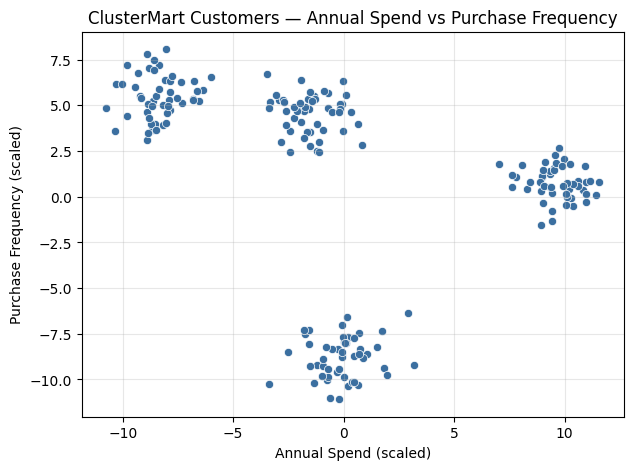

Notice: every dot looks the same color. There is no 'type' column in this dataset.


In [ ]:
# Generate a first look at (anonymized) ClusterMart customer data
X_demo, _ = make_blobs(n_samples=200, centers=4, cluster_std=1.1, random_state=7)

plt.scatter(X_demo[:, 0], X_demo[:, 1], s=35, color='#3b6fa0', edgecolor='white', linewidth=0.5)
plt.title("ClusterMart Customers — Annual Spend vs Purchase Frequency")
plt.xlabel("Annual Spend (scaled)")
plt.ylabel("Purchase Frequency (scaled)")
plt.show()

print("Notice: every dot looks the same color. There is no 'type' column in this dataset.")

### Student Activity (Think & Respond in the Chat)

Look at the scatter plot and imagine you're the clustering algorithm.

**Without using any algorithm, answer in the chat:**

1. **How many customer groups do you think are present?**
2. **Which customers would you group together?**
3. **Would you draw straight boundaries between the groups or curved ones?**

Type your answers in the chat, or simply reply with the number of clusters you think are present (e.g., **4**).


### Reflection

If you compared your answer with a classmate's, you probably got **different groupings**. That's the core problem:

- Humans can eyeball 2D data and roughly agree on clusters.
- But real ClusterMart data has **dozens of features** (spend, frequency, recency, category preferences, return rate...) — far beyond what a human can eyeball.
- We need the *computer* to do this consistently, using a defined **rule**, not a hunch.

**Transition:** So how can we teach a computer to do this?

## Section 2 — Why Supervised Learning Doesn't Work

Quick recap: in **supervised learning**, we train a model using labeled data — inputs *and* the correct answers (e.g. "spam" / "not spam").

The model learns a mapping from input → known output.

**But ClusterMart's customer data has no labels at all.** There's no "Premium" or "Discount Hunter" column to learn from.

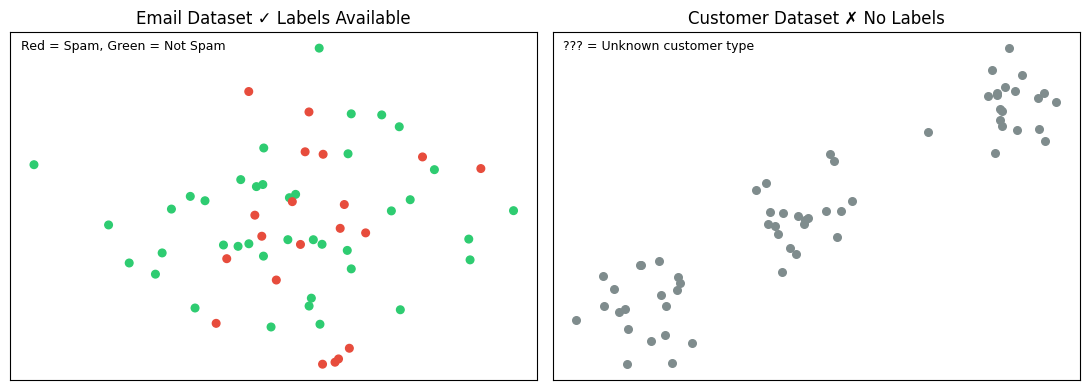

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].set_title("Email Dataset ✓ Labels Available")
colors = ['#e74c3c' if i % 3 == 0 else '#2ecc71' for i in range(60)]
pts = np.random.randn(60, 2)
axes[0].scatter(pts[:, 0], pts[:, 1], c=colors, s=30)
axes[0].text(0.02, 0.95, "Red = Spam, Green = Not Spam", transform=axes[0].transAxes, fontsize=9)

axes[1].set_title("Customer Dataset ✗ No Labels")
pts2, _ = make_blobs(n_samples=60, centers=3, cluster_std=1.0, random_state=3)
axes[1].scatter(pts2[:, 0], pts2[:, 1], c='#7f8c8d', s=30)
axes[1].text(0.02, 0.95, "??? = Unknown customer type", transform=axes[1].transAxes, fontsize=9)

for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

### Mini Exercise (Respond in the Chat)

For each scenario below, decide whether it is **Supervised** or **Unsupervised** learning.

1. Predicting whether a loan applicant will default using historical approved/defaulted loans.
2. Grouping news articles into topics without any topic labels.
3. Predicting house prices using square footage, location, and historical sale prices.
4. Grouping ClusterMart customers based on purchasing behavior when there is no "customer type" column.

**Type your answers in the chat** using the format:

**1) S/U 2) S/U 3) S/U 4) S/U**

For example: `1) S  2) U  3) S  4) U`

Take a minute to think before submitting your answers.

<details>
<summary>Click to reveal the solution</summary>

1. **Supervised** — Historical default outcomes are available as labels.
2. **Unsupervised** — No topic labels are provided.
3. **Supervised** — Historical house prices serve as labels.
4. **Unsupervised** — There is no "customer type" label, making this a clustering problem.

</details>

### **Quiz 1**. Why is Supervised Learning not suitable for a customer segmentation problem using K-Means?
a) Because the dataset does not contain labeled target values.

b) Because the dataset has too many features.

c) Because K-Means requires labeled training data.

d) Because supervised learning cannot handle numerical data.


Ans. **(a)** – Supervised learning requires labeled target values to learn from. In customer segmentation, the goal is to discover hidden groups in unlabeled data, making unsupervised learning (such as K-Means) the appropriate approach.

### Transition

If labels don't exist, we can't train a model to predict them. We need a completely different family of algorithms — ones that find structure in data **without being told the answer**.

## Section 3 — Introducing Clustering

**Clustering** is the task of grouping data points such that points in the same group ("cluster") are more similar to each other than to points in other groups.

No labels required — just the raw features.

Clustering shows up everywhere:

- Spotify grouping listeners with similar taste for playlist recommendations
- Netflix grouping viewers with similar watch histories
- Google Photos grouping photos of the same person
- Image compression (grouping similar pixel colors)
- Customer segmentation (our job today!)

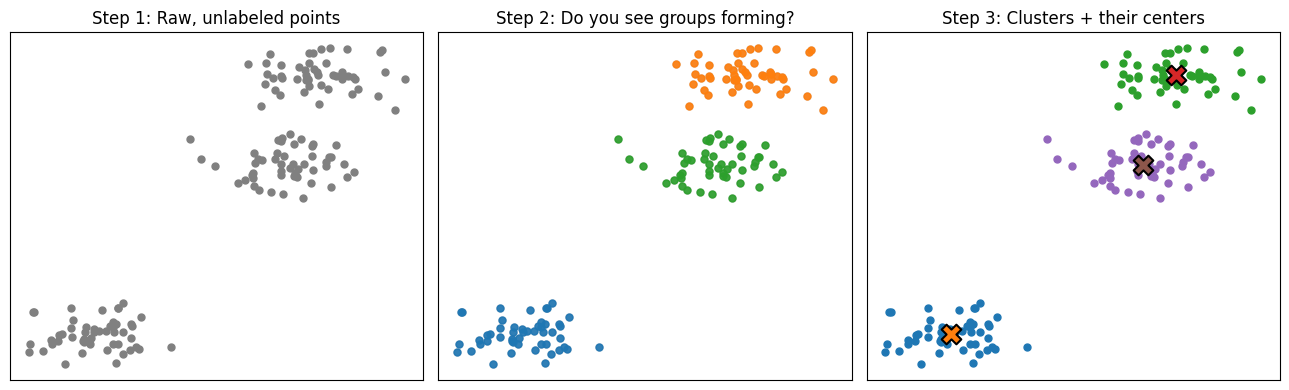

In [ ]:
# Watch random points "settle" into visually distinct clusters as we reveal structure
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

X_c, y_c = make_blobs(n_samples=150, centers=3, cluster_std=0.9, random_state=11)

axes[0].scatter(X_c[:, 0], X_c[:, 1], s=25, color='gray')
axes[0].set_title("Step 1: Raw, unlabeled points")

axes[1].scatter(X_c[:, 0], X_c[:, 1], s=25, color='gray', alpha=0.4)
for k in range(3):
    pts = X_c[y_c == k]
    axes[1].scatter(pts[:, 0], pts[:, 1], s=25, alpha=0.9)
axes[1].set_title("Step 2: Do you see groups forming?")

for k in range(3):
    pts = X_c[y_c == k]
    axes[2].scatter(pts[:, 0], pts[:, 1], s=25)
    axes[2].scatter(*pts.mean(axis=0), marker='X', s=200, edgecolor='black', linewidth=1.5)
axes[2].set_title("Step 3: Clusters + their centers")

for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()


### Reflection

You probably grouped points by **how close together they looked**. That intuitive idea — *closeness* — is exactly what clustering algorithms formalize mathematically.

**Transition:** What actually makes two customers "similar" or "close"? We need to measure it precisely.

## Section 4 — Measuring Similarity

Every customer can be represented as a point in **feature space** — e.g. `(Annual Spend, Purchase Frequency)`.

If two customers are "similar," their points should be **close together** in that space.

The most common way to measure closeness is **Euclidean Distance**:

$$
d(p, q) = \sqrt{(p_1 - q_1)^2 + (p_2 - q_2)^2 + \dots + (p_n - q_n)^2}
$$

It's just the straight-line ("as the crow flies") distance between two points.

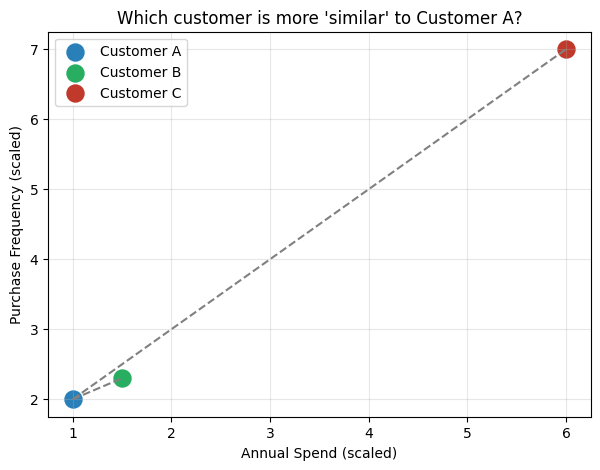

In [ ]:
# Visualize distance between two example customers
customer_A = np.array([1.0, 2.0])   # low spend, low frequency
customer_B = np.array([1.5, 2.3])   # similar to A
customer_C = np.array([6.0, 7.0])   # very different from A

plt.scatter(*customer_A, s=150, label='Customer A', color='#2980b9')
plt.scatter(*customer_B, s=150, label='Customer B', color='#27ae60')
plt.scatter(*customer_C, s=150, label='Customer C', color='#c0392b')

plt.plot([customer_A[0], customer_B[0]], [customer_A[1], customer_B[1]], '--', color='gray')
plt.plot([customer_A[0], customer_C[0]], [customer_A[1], customer_C[1]], '--', color='gray')

plt.legend()
plt.title("Which customer is more 'similar' to Customer A?")
plt.xlabel("Annual Spend (scaled)")
plt.ylabel("Purchase Frequency (scaled)")
plt.show()

The `distance()` function below using the Euclidean distance formula.

In [ ]:
def distance(point1, point2):
    return np.sqrt(np.sum((np.array(point1) - np.array(point2)) ** 2))

d_AB = distance(customer_A, customer_B)
d_AC = distance(customer_A, customer_C)
print(f"Distance A-B: {d_AB:.2f}  (should be small — A and B are similar)")
print(f"Distance A-C: {d_AC:.2f}  (should be large — A and C are different)")

Distance A-B: 0.58  (should be small — A and B are similar)
Distance A-C: 7.07  (should be large — A and C are different)


### AI Corner — Explore Other Distance Metrics

We've been using **Euclidean distance**, but it's not the only option — **Manhattan distance** and **Cosine similarity** are common alternatives, and the right choice depends on the data.

**Try this:** open a chat with an AI assistant (Claude, ChatGPT, etc.) and ask something like:

> "I'm clustering customers using features like annual spend and purchase frequency. When would Euclidean distance, Manhattan distance, and Cosine similarity each be the better choice? Give me a concrete example for each."

Then push a little further with a follow-up, e.g. *"Which one would you use for ClusterMart's data, and why?"*

**Your takeaways (in your own words):** ___


### Transition:
Now that we know how to measure similarity between two points, how do we use it to form entire *groups*?

## Section 5 — Good vs Bad Clusters

**Story:** Two data analysts at ClusterMart each submitted a customer segmentation. The CEO wants to know: **which one is better?**

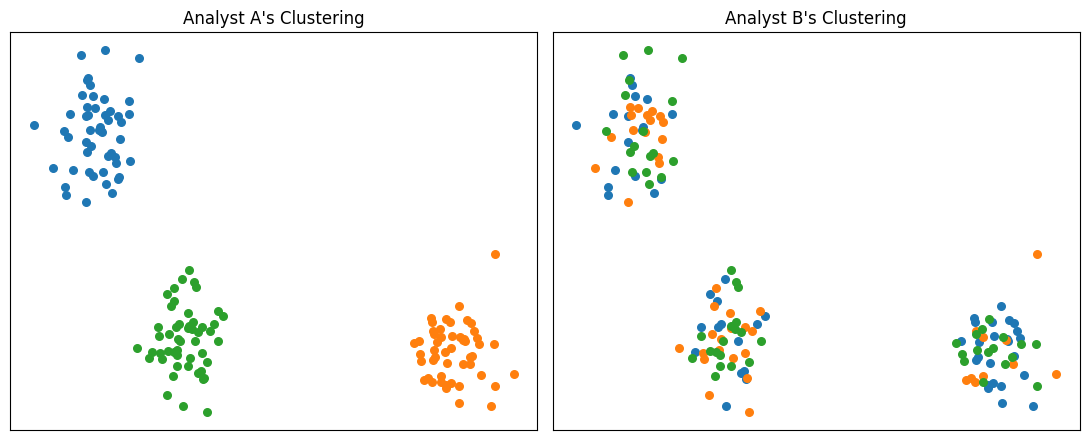

In [ ]:
X_g, y_true = make_blobs(n_samples=150, centers=3, cluster_std=0.8, random_state=21)

# "Good" clustering: matches the natural groups
good_labels = y_true

# "Bad" clustering: random / mismatched assignment
rng = np.random.RandomState(0)
bad_labels = rng.randint(0, 3, size=len(X_g))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for k in range(3):
    axes[0].scatter(X_g[good_labels == k, 0], X_g[good_labels == k, 1], s=30)
    axes[1].scatter(X_g[bad_labels == k, 0], X_g[bad_labels == k, 1], s=30)
axes[0].set_title("Analyst A's Clustering")
axes[1].set_title("Analyst B's Clustering")
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

### Interpreting the Clusters

- **Analyst A's Clustering** forms three clear, compact, and well-separated groups. Points within each cluster are similar, while different clusters are far apart—this is an example of **good clustering**.

- **Analyst B's Clustering** mixes points from different natural groups into the same cluster. The clusters overlap significantly and fail to capture the underlying structure of the data, making it a **poor clustering**.




### Introducing two key ideas (intuition only, no formulas yet)

- **Intra-cluster distance:** how spread out points are *within* the same cluster. Smaller = tighter, more cohesive groups.
- **Inter-cluster distance:** how far apart different clusters are *from each other*. Larger = more distinct, separable groups.

### Reflection

A **good clustering** has:
- Small intra-cluster distance (points within a group are close together)
- Large inter-cluster distance (different groups are far apart)

Analyst A's clustering has tight, well-separated groups. Analyst B's is essentially random noise.



### Q. What metric can we use to evaluate our Clustering?

- Ideally, the resultant clusters should make **business sense**

- Say that you are working for a shirt manufacturing company, then you should have 3 clusters: small, medium, large.

- It does not make sense to have 100 clusters!

- To evaluate the results of clustering, we can also use the same distance metrics we used for supervised learning problems, like Euclidean Distance,etc.

### Transition
Can we automate the process of finding groups like Analyst A's?

## Section 6 — Inventing K-Means

**Story:** The CEO leans back and asks:

> *"If you had to automate this clustering process yourself — write out the steps — what would you do?"*



### Reveal

If your steps looked something like:

1. Pick some starting "center" points
2. Assign every customer to their nearest center
3. Move each center to the average position of the customers assigned to it
4. Repeat steps 2–3 until nothing changes

**...you've just invented K-Means.** This is exactly the algorithm, and it's been one of the most widely used clustering methods since the 1960s.

### Reflection

K-Means isn't magic — it's a very logical, iterative process that you basically invented yourself. Next, let's watch it run step by step on real data.

## Section 7 — K-Means in Action

Let's watch K-Means converge, iteration by iteration, on a sample of ClusterMart customers.

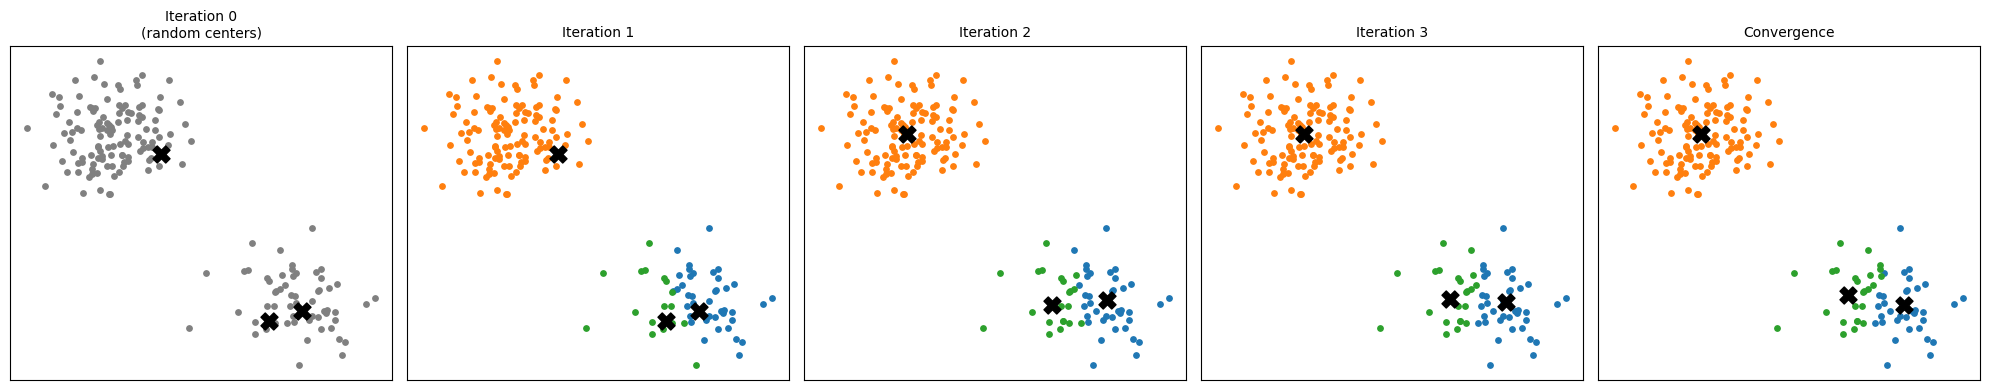

In [ ]:
def kmeans_step_by_step(X, k, n_iters=4, seed=42):
    rng = np.random.RandomState(seed)
    centroids = X[rng.choice(len(X), k, replace=False)]
    history = [(centroids.copy(), None)]

    for _ in range(n_iters):
        # Assignment step: assign each point to nearest centroid
        dists = np.linalg.norm(X[:, None, :] - centroids[None, :, :], axis=2)
        labels = np.argmin(dists, axis=1)
        history.append((centroids.copy(), labels.copy()))

        # Update step: move centroids to mean of assigned points
        new_centroids = np.array([
            X[labels == j].mean(axis=0) if np.any(labels == j) else centroids[j]
            for j in range(k)
        ])
        centroids = new_centroids

    dists = np.linalg.norm(X[:, None, :] - centroids[None, :, :], axis=2)
    labels = np.argmin(dists, axis=1)
    history.append((centroids.copy(), labels.copy()))
    return history

X_iter, _ = make_blobs(n_samples=180, centers=3, cluster_std=1.0, random_state=5)
history = kmeans_step_by_step(X_iter, k=3, n_iters=3)

fig, axes = plt.subplots(1, len(history), figsize=(4 * len(history), 4))
titles = ["Iteration 0\n(random centers)"] + [f"Iteration {i}" for i in range(1, len(history)-1)] + ["Convergence"]
for ax, (centroids, labels), title in zip(axes, history, titles):
    if labels is None:
        ax.scatter(X_iter[:, 0], X_iter[:, 1], color='gray', s=15)
    else:
        for j in range(3):
            ax.scatter(X_iter[labels == j, 0], X_iter[labels == j, 1], s=15)
    ax.scatter(centroids[:, 0], centroids[:, 1], marker='X', s=150, c='black')
    ax.set_title(title, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

Notice the two repeating steps:

- **Assignment Step:** every point joins the cluster of its nearest centroid (colors change)
- **Update Step:** each centroid moves to the average of its assigned points (✕ markers move)



### AI Corner — Get a Code Review

You have to built K-Means from scratch. Before moving on, put your implementation in front of an AI assistant and ask it to review the code.

**Try this:** paste your `initialize_centroids`, `assign_clusters`, `update_centroids`, and `fit` functions into an AI chat and ask:

> "Review this K-Means implementation. Are there any bugs or edge cases I'm missing — for example, what happens if a cluster ends up with zero points assigned to it after an update step?"

This is a real edge case production K-Means implementations have to handle. See what the AI suggests, and note it below.

**What AI flagged (bugs, edge cases, or improvements):** ___

## Section 8 — Why Does the Centroid Move to the Mean?

**Story:** A curious teammate asks: *"Why do we move each centroid to the **average** position? Why not the median, or some other point?"*

Let's investigate by testing many candidate centroid positions for a single cluster of points, and measuring the **total squared distance** from the centroid to all its points.

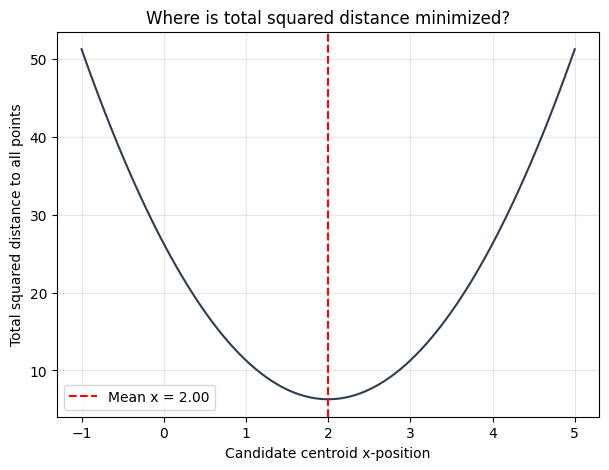

In [ ]:
cluster_points = np.array([[1, 2], [2, 3], [1.5, 1], [3, 2], [2.5, 3.5]])
true_mean = cluster_points.mean(axis=0)

# Try many candidate centroid x-positions along a line through the mean
candidate_xs = np.linspace(true_mean[0] - 3, true_mean[0] + 3, 100)
total_sq_dist = []
for cx in candidate_xs:
    candidate = np.array([cx, true_mean[1]])
    total_sq_dist.append(np.sum((cluster_points - candidate) ** 2))

plt.plot(candidate_xs, total_sq_dist, color='#2c3e50')
plt.axvline(true_mean[0], color='red', linestyle='--', label=f'Mean x = {true_mean[0]:.2f}')
plt.xlabel("Candidate centroid x-position")
plt.ylabel("Total squared distance to all points")
plt.title("Where is total squared distance minimized?")
plt.legend()
plt.show()

### Within-Cluster Sum of Squares (WCSS)

$$
WCSS = \sum_{\text{points } p \text{ in cluster}} \|p - centroid\|^2
$$

The curve above dips to its lowest point exactly at the mean — that's not a coincidence. The **mean is the single point that minimizes WCSS** for a set of points, which is exactly why K-Means' update step moves each centroid to the mean of its assigned points.

### **Quiz 2**. Why does the centroid move to the mean during the update step instead of the median?

a) Because the mean minimizes the total squared distance (WCSS).

b) Because the median is computationally expensive.

c) Because the mean is always one of the data points.

d) Because K-Means requires an odd number of points.


Ans. **(a)**- The objective of K-Means is to minimize the Within-Cluster Sum of Squares (WCSS). The arithmetic mean is the point that minimizes this squared distance, making it the optimal centroid update.

### AI Corner — Ask AI to Prove It

The quiz above told you *that* the mean minimizes WCSS — but why is that mathematically true?

**Ask your AI assistant:**

> "Can you show me, step by step, why the arithmetic mean minimizes the sum of squared distances to a set of points? What happens if I use the median instead?"

See if you can follow the logic (hint: it involves taking a derivative and setting it to zero). You don't need to memorize the proof — just get comfortable asking AI to unpack a claim you're told to accept.

**One thing I learned from AI's explanation:** ___

## Section 9 — Choosing K

**Story:** Marketing comes back with a question:

> *"Great, K-Means groups customers... but how many groups should we actually create? 2? 5? 10?"*

K-Means requires *us* to decide K in advance. Let's explore what happens as we vary it.

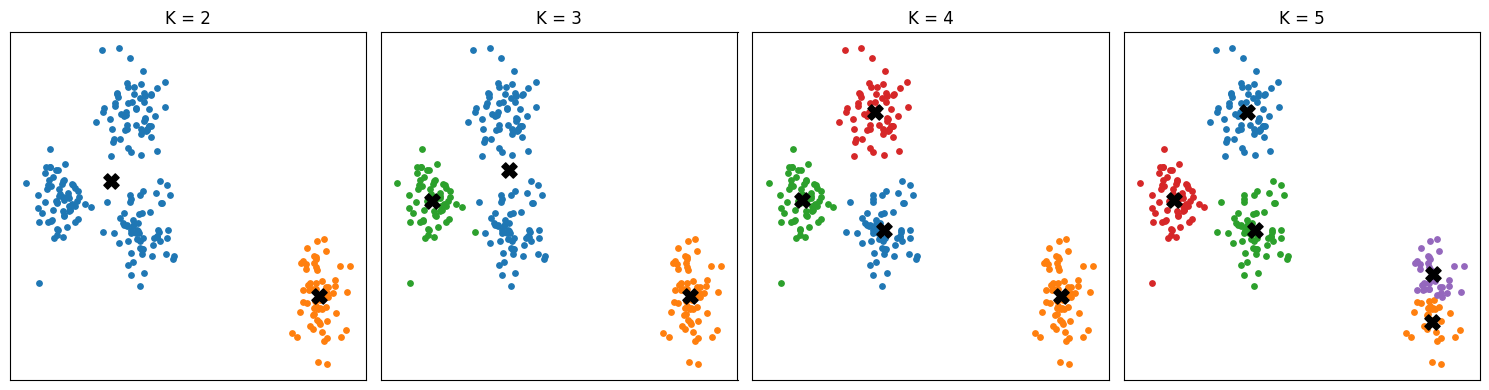

In [ ]:
X_k, _ = make_blobs(n_samples=250, centers=4, cluster_std=0.9, random_state=15)

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for ax, k in zip(axes, [2, 3, 4, 5]):
    model = KMeans(n_clusters=k, random_state=15, n_init=10).fit(X_k)
    for j in range(k):
        ax.scatter(X_k[model.labels_ == j, 0], X_k[model.labels_ == j, 1], s=15)
    ax.scatter(model.cluster_centers_[:, 0], model.cluster_centers_[:, 1], marker='X', s=120, c='black')
    ax.set_title(f"K = {k}")
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

Every value of K produces *some* clustering — even wrong ones. We need a quantitative way to pick a good K.

We'll use **WCSS** (introduced in Section 9): the total squared distance from every point to its assigned centroid, summed across all clusters. Lower WCSS = tighter clusters — but WCSS *always* decreases as K increases (more clusters = points closer to their own centroid). So we look for the point of **diminishing returns**: the "elbow".

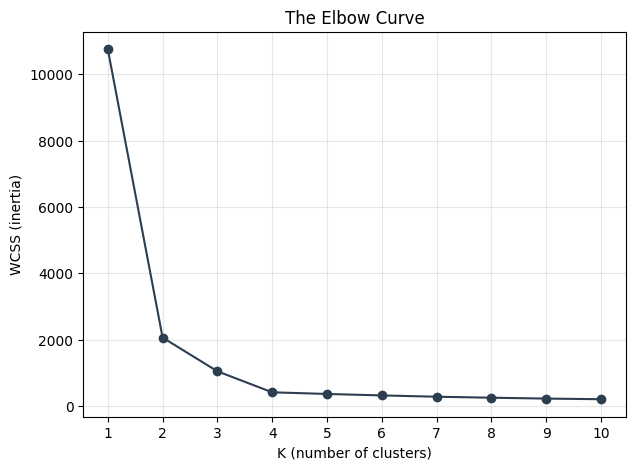

In [ ]:
wcss_values = []
K_range = range(1, 11)
for k in K_range:
    model = KMeans(n_clusters=k, random_state=15, n_init=10).fit(X_k)
    wcss_values.append(model.inertia_)  # inertia_ is sklearn's built-in WCSS

plt.plot(list(K_range), wcss_values, marker='o', color='#2c3e50')
plt.xlabel("K (number of clusters)")
plt.ylabel("WCSS (inertia)")
plt.title("The Elbow Curve")
plt.xticks(list(K_range))
plt.show()

**How do we determine the right k?**
- In K-Means, **$K$** is a hyperparameter and it can be determined through:

1. **Domain Knowledge**

  - If our problem contains a fixed number of clusters/groups all the time, then ‘**K**’ will be determined using the domain knowledge.

2. **Elbow Method or Knee Method**

 - In this method, we calculate **Within-Cluster Sum of Square (WCSS)**


**Q. Why not pick the K with the lowest value of WCSS?**
- The value of WCSS would be the lowest (equals to $0$) when each and every point in the dataset is a cluster itself.(i.e., the model is overfitting)

- This is not what we would want as a result of clustering, is it?

### **Quiz 3.** What happens to WCSS as K increases (holding data fixed)?
   - a) Always increases
   - b) Always decreases (or stays the same)
   - c) Increases then decreases
   - d) Unpredictable

Ans. **(b)** — more clusters means points are always at least as close to *some* centroid, so WCSS is monotonically non-increasing in K.


### Reflection

Choosing K is a **trade-off**: too few clusters lump together dissimilar customers; too many clusters split apart genuinely similar customers and start to overfit noise. The elbow method gives us a principled starting point — but as we'll see next, it's not the only tool we should use.

## Section 10 — Measuring Cluster Quality

**Story:** The CEO isn't satisfied with just eyeballing an elbow curve:

> *"How do we know whether these clusters are actually GOOD, not just 'good enough'?"*

Let's zoom into a **single customer** and think about two distances:

- Their average distance to other points in **their own cluster** (call it *a*)
- Their average distance to points in the **nearest other cluster** (call it *b*)

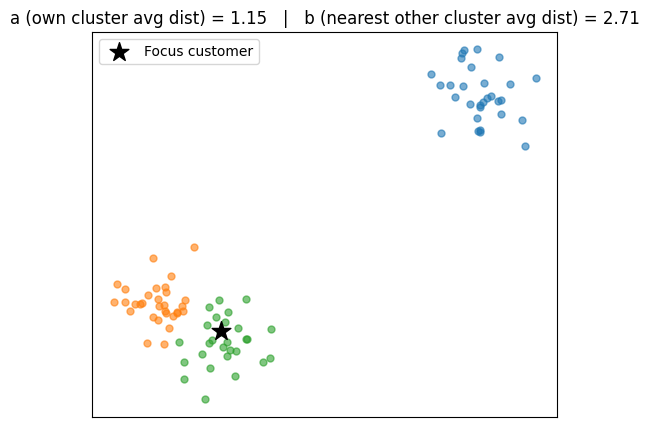

In [ ]:
X_s, y_s = make_blobs(n_samples=90, centers=3, cluster_std=0.8, random_state=25)
model_s = KMeans(n_clusters=3, random_state=25, n_init=10).fit(X_s)
labels_s = model_s.labels_

focus_idx = 10
focus_point = X_s[focus_idx]
focus_cluster = labels_s[focus_idx]

plt.figure(figsize=(6, 5))
for j in range(3):
    plt.scatter(X_s[labels_s == j, 0], X_s[labels_s == j, 1], s=25, alpha=0.6)
plt.scatter(*focus_point, s=200, c='black', marker='*', label='Focus customer', zorder=5)

# distance to own-cluster points
own_cluster_pts = X_s[(labels_s == focus_cluster)]
a = np.mean([distance(focus_point, p) for p in own_cluster_pts if not np.array_equal(p, focus_point)])

# distance to nearest other cluster
other_cluster_dists = {}
for j in range(3):
    if j == focus_cluster:
        continue
    pts = X_s[labels_s == j]
    other_cluster_dists[j] = np.mean([distance(focus_point, p) for p in pts])
nearest_other = min(other_cluster_dists, key=other_cluster_dists.get)
b = other_cluster_dists[nearest_other]

plt.legend()
plt.title(f"a (own cluster avg dist) = {a:.2f}   |   b (nearest other cluster avg dist) = {b:.2f}")
plt.xticks([]); plt.yticks([])
plt.show()

### Silhouette Score (intuition)

For each point, the **silhouette score** compares *a* (distance to its own cluster) with *b* (distance to the nearest other cluster):

$$
s = \frac{b - a}{\max(a, b)}
$$

- **Close to +1:** the point is well inside its own cluster, far from others → great clustering
- **Close to 0:** the point sits right on the border between two clusters
- **Negative:** the point is probably in the *wrong* cluster

Averaging this score across all points gives an overall **Silhouette Score** for a clustering, ranging from -1 to +1.

K = 2:  Silhouette Score = 0.743
K = 3:  Silhouette Score = 0.604
K = 4:  Silhouette Score = 0.705
K = 5:  Silhouette Score = 0.586
K = 6:  Silhouette Score = 0.522
K = 7:  Silhouette Score = 0.438


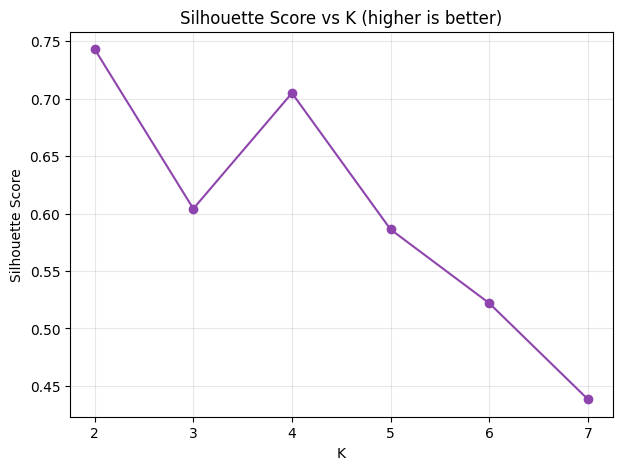

In [ ]:
silhouette_values = []
for k in range(2, 8):  # silhouette needs at least 2 clusters
    model = KMeans(n_clusters=k, random_state=15, n_init=10).fit(X_k)
    score = silhouette_score(X_k, model.labels_)
    silhouette_values.append(score)
    print(f"K = {k}:  Silhouette Score = {score:.3f}")

plt.plot(range(2, 8), silhouette_values, marker='o', color='#8e44ad')
plt.xlabel("K")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs K (higher is better)")
plt.show()

### Reflection

Higher silhouette scores indicate better-defined clusters. Combined with the elbow method, this gives us a much more confident way to choose K — not just eyeballing a curve, but backing it up with a quantitative quality metric.

## Choosing the Optimal Value of K

There is no single metric that always gives the perfect value of **K**, so we usually consider multiple evaluation methods together.

### Elbow Method
Look for the point where the WCSS curve starts to flatten. This indicates that adding more clusters provides only marginal improvement.

For our dataset, the elbow appears around **K = 4**.


### Silhouette Score
Choose the value of **K** with the highest (or a near-highest) Silhouette Score, as it indicates well-separated and compact clusters.

Although **K = 2** has the highest score, **K = 4** also has a high score while capturing the natural four-cluster structure of the dataset.


### Final Choice

Considering both metrics together:

- **Elbow Method → K = 4**
- **Silhouette Score → K = 4 is still a strong choice**

Hence, **K = 4** is the most appropriate number of clusters for this dataset.

## Section 11 — Building ClusterMart's Segmentation Engine

**Story:** The company finally hands you the real deal — an (anonymized, simulated) sample of actual ClusterMart customer data. Time to put everything together into a real pipeline.

In [ ]:
# Simulate a realistic ClusterMart customer dataset
rng = np.random.RandomState(42)
n = 400

# Premium customers: high spend, high frequency, low discount usage
premium = np.column_stack([
    rng.normal(8000, 900, 100),   # annual spend
    rng.normal(28, 4, 100),       # purchase frequency (per year)
    rng.normal(5, 3, 100),        # discount usage (%)
])
# Frequent buyers: moderate spend, very high frequency
frequent = np.column_stack([
    rng.normal(3500, 600, 100),
    rng.normal(35, 5, 100),
    rng.normal(20, 5, 100),
])
# Discount hunters: low-moderate spend, moderate frequency, high discount usage
discount = np.column_stack([
    rng.normal(1800, 400, 100),
    rng.normal(15, 4, 100),
    rng.normal(65, 8, 100),
])
# Occasional visitors: low spend, low frequency
occasional = np.column_stack([
    rng.normal(600, 250, 100),
    rng.normal(3, 2, 100),
    rng.normal(30, 15, 100),
])

customer_data = np.vstack([premium, frequent, discount, occasional])
np.random.shuffle(customer_data)
customer_data[:, 2] = np.clip(customer_data[:, 2], 0, 100)
customer_data[:, 1] = np.clip(customer_data[:, 1], 0, None)
customer_data[:, 0] = np.clip(customer_data[:, 0], 0, None)

import pandas as pd
df = pd.DataFrame(customer_data, columns=['annual_spend', 'purchase_frequency', 'discount_usage_pct'])
df.head()

,annual_spend,purchase_frequency,discount_usage_pct
0,2078.482546,9.373356,60.752024
1,743.145695,3.692977,50.462106
2,4791.909475,43.224839,24.147028
3,2088.668826,15.710804,85.215459
4,3369.391278,38.558074,21.352284


       annual_spend  purchase_frequency  discount_usage_pct
count    400.000000          400.000000          400.000000
mean    3471.825727           20.288166           30.839665
std     2824.149023           12.707222           24.645050
min        0.000000            0.000000            0.000000
25%     1058.803214            7.251780            8.908426
50%     2591.979597           22.051190           21.774106
75%     5020.968672           30.312308           56.978447
max     9667.050366           50.394404           85.215459


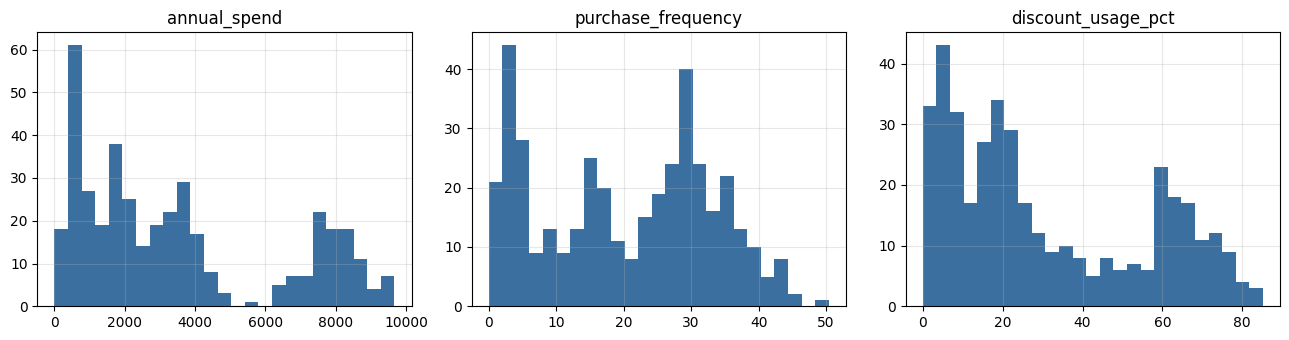

In [ ]:
# Quick EDA
print(df.describe())
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for ax, col in zip(axes, df.columns):
    ax.hist(df[col], bins=25, color='#3b6fa0')
    ax.set_title(col)
plt.tight_layout()
plt.show()

### Feature Scaling

Notice `annual_spend` ranges into the **thousands** while `discount_usage_pct` ranges 0–100. Since K-Means relies on Euclidean distance, unscaled features would let `annual_spend` completely dominate the distance calculation. We must **standardize** features before clustering.

### **Quiz 4**. Why is feature scaling important before running K-Means?

a) It makes the algorithm run faster.

b) It ensures features with larger scales do not dominate the distance calculation.

c) It automatically chooses the best value of K.

d) It guarantees better clustering results.

Ans. **(b)** - K-Means relies on Euclidean distance. Without scaling, features with larger numerical ranges can dominate the distance calculation and disproportionately influence the clustering.

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
print("Before scaling (mean, std):", df.mean().values.round(1), df.std().values.round(1))
print("After scaling (mean, std): ", X_scaled.mean(axis=0).round(1), X_scaled.std(axis=0).round(1))

Before scaling (mean, std): [3471.8   20.3   30.8] [2824.1   12.7   24.6]
After scaling (mean, std):  [ 0. -0. -0.] [1. 1. 1.]


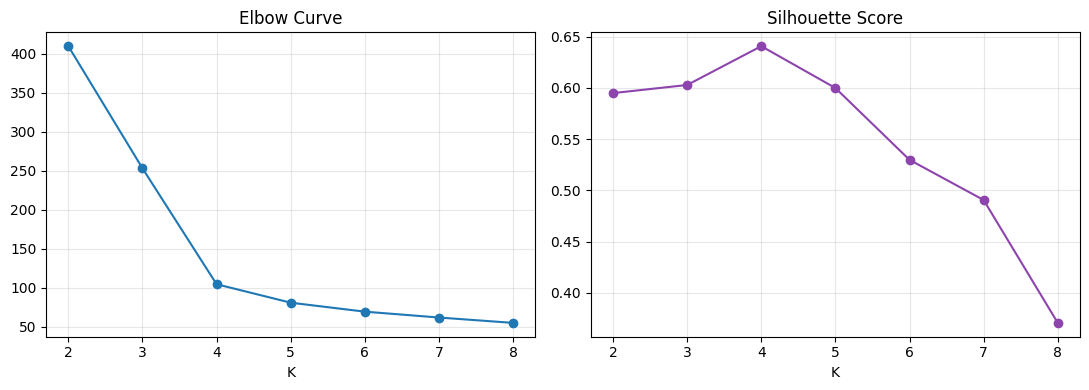

In [ ]:
# Choose K using elbow + silhouette (informed by Sections 10-11)
wcss, sil = [], []
for k in range(2, 9):
    model = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled)
    wcss.append(model.inertia_)
    sil.append(silhouette_score(X_scaled, model.labels_))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(range(2, 9), wcss, marker='o'); axes[0].set_title("Elbow Curve"); axes[0].set_xlabel("K")
axes[1].plot(range(2, 9), sil, marker='o', color='#8e44ad'); axes[1].set_title("Silhouette Score"); axes[1].set_xlabel("K")
plt.tight_layout()
plt.show()

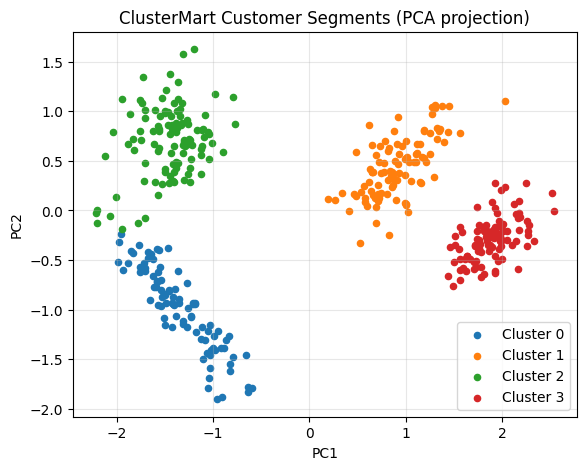

In [ ]:
# Apply final K-Means model
final_k = 4
final_model = KMeans(n_clusters=final_k, random_state=42, n_init=10)
df['cluster'] = final_model.fit_predict(X_scaled)

# Visualize with PCA (reduce 3 features to 2D for plotting)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(6.5, 5))
for c in range(final_k):
    mask = df['cluster'] == c
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], s=20, label=f'Cluster {c}')
plt.legend()
plt.title("ClusterMart Customer Segments (PCA projection)")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.show()

In [ ]:
# Interpret each cluster with a business-friendly profile table
cluster_profile = df.groupby('cluster')[['annual_spend', 'purchase_frequency', 'discount_usage_pct']].mean().round(1)
cluster_profile['count'] = df['cluster'].value_counts().sort_index()
cluster_profile

,annual_spend,purchase_frequency,discount_usage_pct,count
cluster,,,,
0,588.1,3.4,29.3,92
1,3564.1,34.7,19.4,100
2,1736.6,14.1,66.4,108
3,7906.5,28.1,5.3,100


### Business Discussion

Looking at the cluster profile table above, assign a business-friendly name to each cluster. For example:

| Cluster trait | Likely Segment | Marketing Idea |
|---|---|---|
| High spend, high frequency, low discount use | **Premium Customers** | VIP loyalty perks, early access to new products |
| Moderate spend, very high frequency | **Frequent Buyers** | Subscribe & save, bundle deals |
| Low-moderate spend, high discount use | **Discount Hunters** | Flash sales, coupon campaigns |
| Low spend, low frequency | **Occasional Visitors** | Re-engagement email campaigns, win-back offers |

**Your task:** match each `cluster` number in the table above to one of these segments, based on its actual averages.

### AI Corner — Sanity-Check Your Segment Names

You just assigned business-friendly names to each cluster based on the averages. Now compare notes with AI:

> "Here are 4 customer clusters: [describe each cluster's averages for annual_spend, purchase frequency, discount usage]. Suggest a business-friendly name and one marketing action for each."

Compare AI's suggestions to your own. Did it propose a name or campaign idea you like better than yours?

**AI's suggestions vs. mine:** ___

### Discussion — K-Means's Assumptions

K-Means implicitly assumes:

- **Spherical (round, blob-shaped) clusters** — because it uses distance-to-a-single-center, it can't represent curved or elongated shapes.
- **Similar cluster sizes/density** — the "average" gets pulled around by imbalanced groups.
- **Euclidean distance is meaningful** — this breaks down for some data types (e.g. categorical data, or data on a circle/sphere).
- **Sensitivity to outliers** — since it uses the *mean*, a few extreme points can drag a centroid away from the real cluster center.



## Section 12 — Mission Complete

**Story:** You walk back into the CEO's office with your laptop open.

You present:

- A working customer segmentation pipeline
- 4 clearly interpretable customer segments (Premium, Frequent, Discount Hunters, Occasional)
- A quantitative justification for the number of segments (elbow + silhouette)
- An understanding of when this approach would and wouldn't work

Marketing approves the plan and begins designing campaigns around your segments.

**Congratulations — you've built ClusterMart's first Customer Segmentation Engine.**

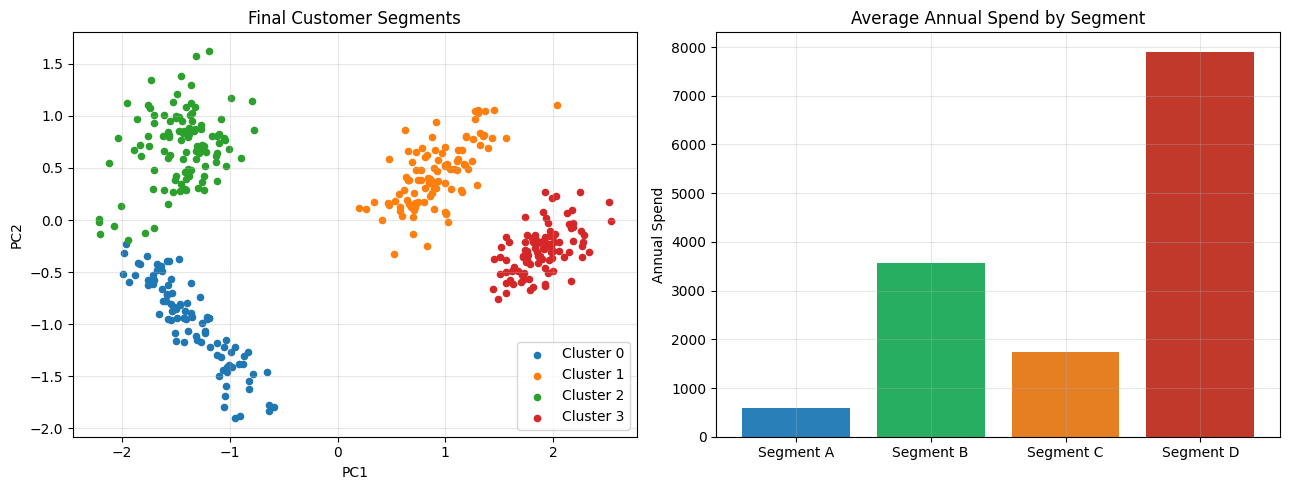

In [ ]:
# Final dashboard: segments + a mock business-insights summary
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for c in range(final_k):
    mask = df['cluster'] == c
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], s=20, label=f'Cluster {c}')
axes[0].legend()
axes[0].set_title("Final Customer Segments")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")

segment_names = ['Segment A', 'Segment B', 'Segment C', 'Segment D']
avg_spend = df.groupby('cluster')['annual_spend'].mean().values
axes[1].bar(segment_names, avg_spend, color=['#2980b9', '#27ae60', '#e67e22', '#c0392b'])
axes[1].set_title("Average Annual Spend by Segment")
axes[1].set_ylabel("Annual Spend")

plt.tight_layout()
plt.show()

### Final Reflection

In a few sentences, summarize:

- What business problem did we solve?
- What ML concept made each step possible? (unsupervised learning → distance → clustering quality → K-Means → choosing K → evaluation)


**Your summary here:**



## Wrap Up
* Understood how clustering helps uncover hidden patterns without labeled data.
* Learned how K-Means groups similar data points using centroids and distance.
* Implemented K-Means step by step and observed how clusters evolve iteratively.
* Used the Elbow Method and Silhouette Score to select an appropriate number of clusters.
* Learned why feature scaling is essential for distance-based algorithms.
* Interpreted clusters as meaningful business segments.
* Discussed the assumptions and limitations of K-Means and when it works well.